In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans


Cargando datos

In [50]:
compras = [
    8000, 10000, 13000, 17000, 20000,
    22000, 23000, 25000, 27000, 28000,
    30500, 33500, 37000, 38000, 39500,
    42000, 44000, 48000, 53000, 54000
]

movimientos = [
    8, 4, 10, 7, 18,
    9, 23, 5, 19, 25,
    22, 19, 24, 13, 8,
    12, 5, 9, 9, 13
]
print(f"total de registros: {len(compras)} montos y {len(movimientos)} movimientos")

total de registros: 20 montos y 20 movimientos


Graficando compras y movimientos

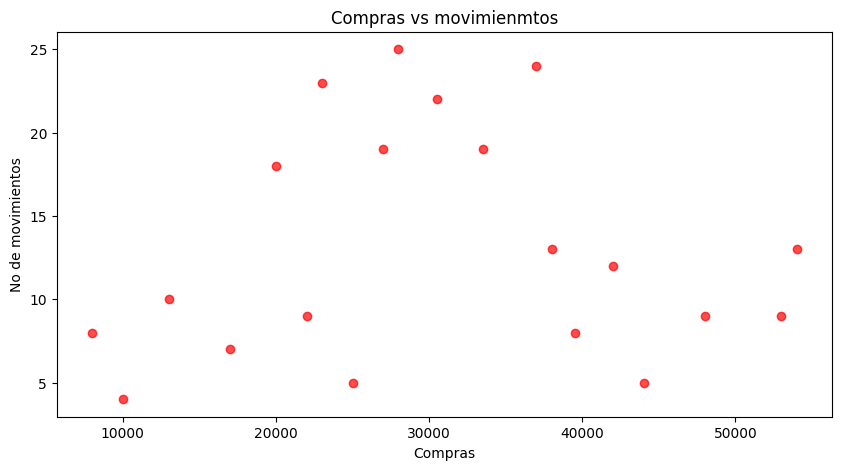

In [51]:
plt.figure(figsize=(10,5))
plt.scatter(compras, movimientos,color="red", alpha=0.7)
plt.title("Compras vs movimienmtos")
plt.xlabel("Compras")
plt.ylabel("No de movimientos")
plt.show()

In [52]:
df = pd.DataFrame({
    "compras": compras,
    "movimientos": movimientos
})

Escalamos los datos

In [53]:
escalador = MinMaxScaler().fit(df.values)
df_escalados = escalador.transform(df.values)
df_escalados = pd.DataFrame(df_escalados, columns=df.columns)
df_escalados.head()

,compras,movimientos
0,0.000000,0.190476
1,0.043478,0.000000
2,0.108696,0.285714
3,0.195652,0.142857
4,0.260870,0.666667


Creamos el modelo basado en k-means

In [54]:
kmeans= KMeans(n_clusters=3).fit(df_escalados.values)

In [55]:
print(kmeans.labels_)

[1 1 1 1 0 1 0 1 0 0 0 0 0 2 2 2 2 2 2 2]


Modificando dataframe para asociar el numero del cluster al que pertenece un cliente

In [56]:
df_escalados['cluster']=kmeans.labels_
df_escalados.head()

,compras,movimientos,cluster
0,0.000000,0.190476,1
1,0.043478,0.000000,1
2,0.108696,0.285714,1
3,0.195652,0.142857,1
4,0.260870,0.666667,0


In [57]:
print(f"Ubicacion de los centros: \n{kmeans.cluster_centers_}")
print(f"Inercia: {kmeans.inertia_}")

Ubicacion de los centros: 
[[0.44409938 0.82993197]
 [0.17028986 0.15079365]
 [0.81521739 0.27891156]]
Inercia: 0.6031488584871942


Desescalamos los valores

In [58]:
centroides = escalador.inverse_transform(kmeans.cluster_centers_)

In [59]:
df['cluster']=kmeans.labels_

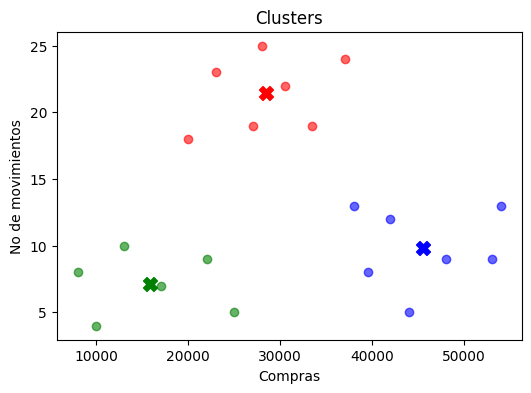

In [61]:
plt.figure(figsize=(6,4))
colores = ["red", "green", "blue", "orange", "brown", "pink", "cyan", "magenta"]
for i in range(kmeans.n_clusters):
    cluster_data = df[df["cluster"]==i]
    plt.scatter(
        cluster_data["compras"],
        cluster_data["movimientos"],
        color=colores[i],
        label=f"cluster {i}",
        alpha=0.6
    )
    plt.scatter(
        centroides[i,0],
        centroides[i,1],
        color=colores[i],
        marker="X",
        s=100,
        label=f"Centroide {i}"
    )

    plt.title("Clusters")
    plt.xlabel("Compras")
    plt.ylabel("No de movimientos")
    #plt.legend()
    
